In [1]:
"""
Exploratory Data Analysis (EDA) & Data Visualization

Before finalizing the predictive models, we must understand the underlying patterns and statistical distributions within our dataset. This notebook focuses on visual storytelling—identifying how Oscar winners differ from non-winners in terms of financial success, audience reception, and genre trends.

Key visualizations:
+ Visualizing the scarcity of Oscar winners;
+ Identifying multi-collinearity and relationships between continuous variables;
+ Comparing Budget vs. Revenue for winners and non-winners;
+ Analyzing how TMDB 'vote_average' impacts Academy recognition;
+ Discovering which genres are most frequently associated with Oscar success ("Oscar Bait").
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.container as pltcontainer
import seaborn as sns

In [2]:
# Set global aesthetic style for a professional "Management Consulting" look
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16

In [3]:
df = pd.read_csv('../data/processed/oscar_tmdb_cleaned.csv')

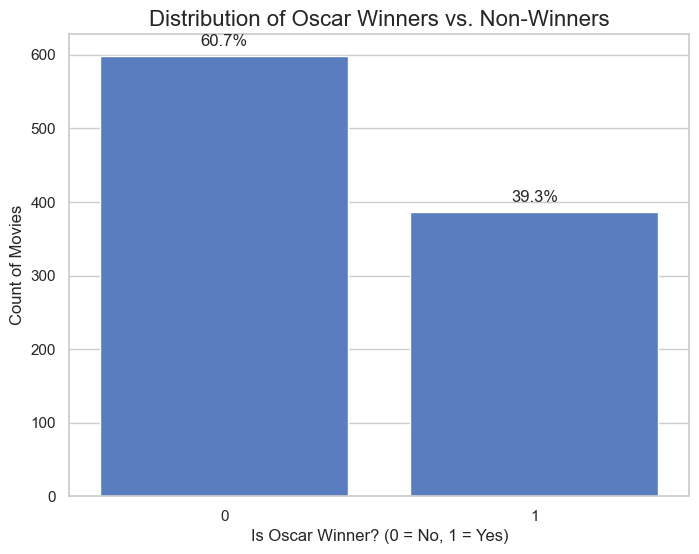

In [4]:
"""
Visualizing the extreme rarity of Oscar winners. This justification is crucial for our modeling strategy (using scale_pos_weight).
"""

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='is_oscar_winner', data=df)
plt.title('Distribution of Oscar Winners vs. Non-Winners')
plt.xlabel('Is Oscar Winner? (0 = No, 1 = Yes)')
plt.ylabel('Count of Movies')

total = len(df)
for container in ax.containers:
    if isinstance(container, pltcontainer.BarContainer):
        labels = [f'{100 * bar.get_height() / total:.1f}%' for bar in container]
        ax.bar_label(container, labels=labels, padding=5, fontsize=12)
plt.show()

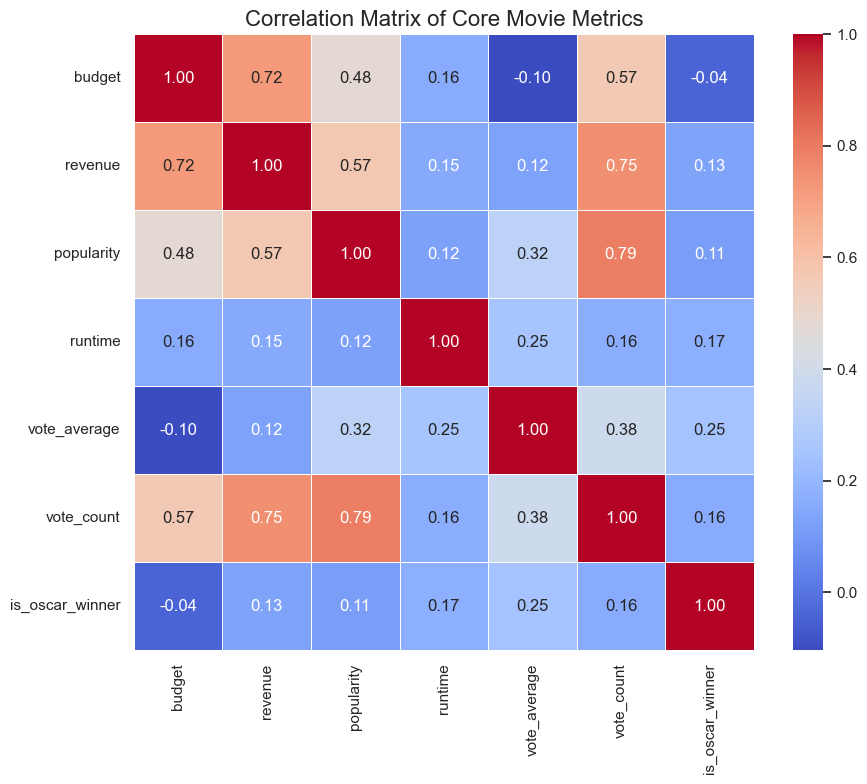

In [5]:
"""
Heatmap to identify relationships between key numerical features. We look for high correlation between 'budget', 'revenue', and 'popularity'.
"""

cols_to_corr = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count', 'is_oscar_winner']
corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Core Movie Metrics')
plt.show()

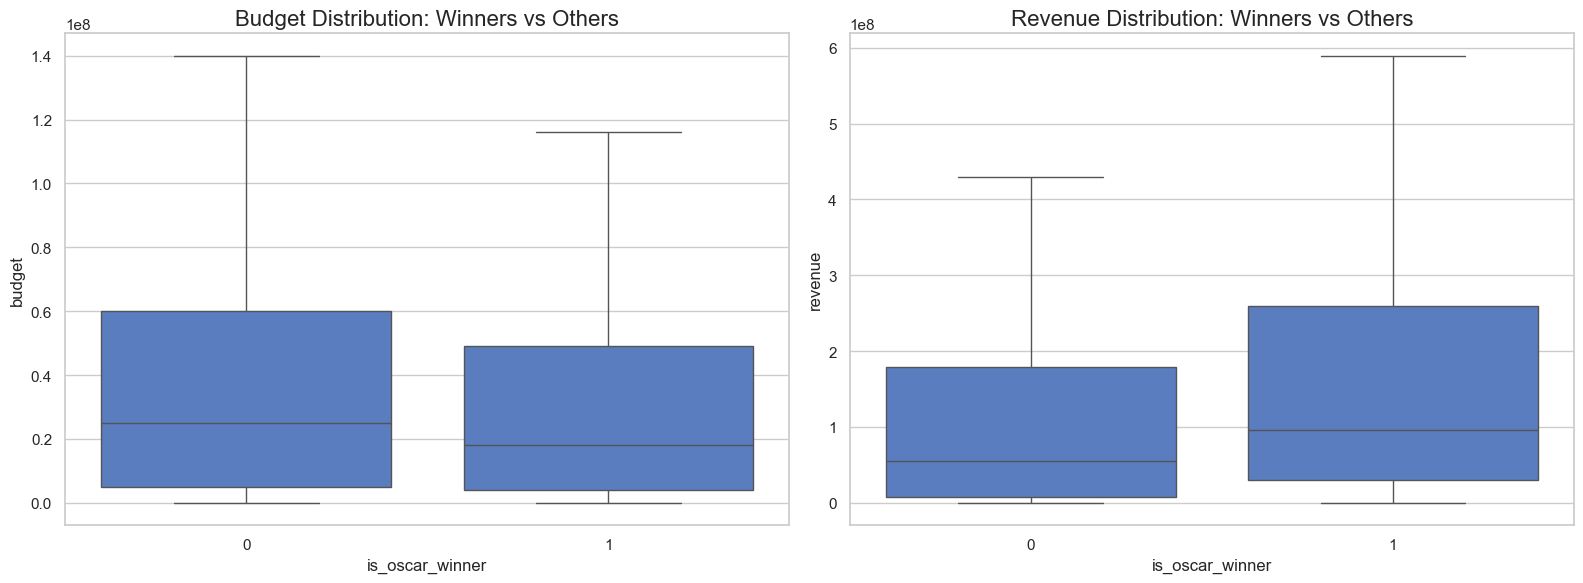

In [6]:
"""
Boxplots to compare distributions of Budget and Revenue. Oscars often favor "prestige" films which might have different financial profiles than typical summer blockbusters.
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='is_oscar_winner', y='budget', data=df, ax=ax1, showfliers=False)
ax1.set_title('Budget Distribution: Winners vs Others')

sns.boxplot(x='is_oscar_winner', y='revenue', data=df, ax=ax2, showfliers=False)
ax2.set_title('Revenue Distribution: Winners vs Others')

plt.tight_layout()
plt.show()

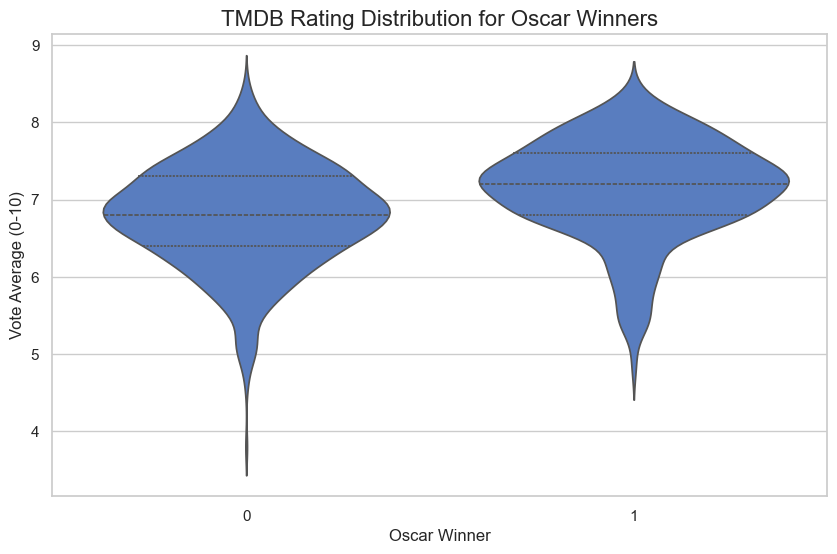

In [7]:
"""
Violin plot showing the density and distribution of ratings. Oscar winners typically cluster at higher rating scores (7.0+).
"""

plt.figure(figsize=(10, 6))
sns.violinplot(x='is_oscar_winner', y='vote_average', data=df, inner="quart")
plt.title('TMDB Rating Distribution for Oscar Winners')
plt.xlabel('Oscar Winner')
plt.ylabel('Vote Average (0-10)')
plt.show()

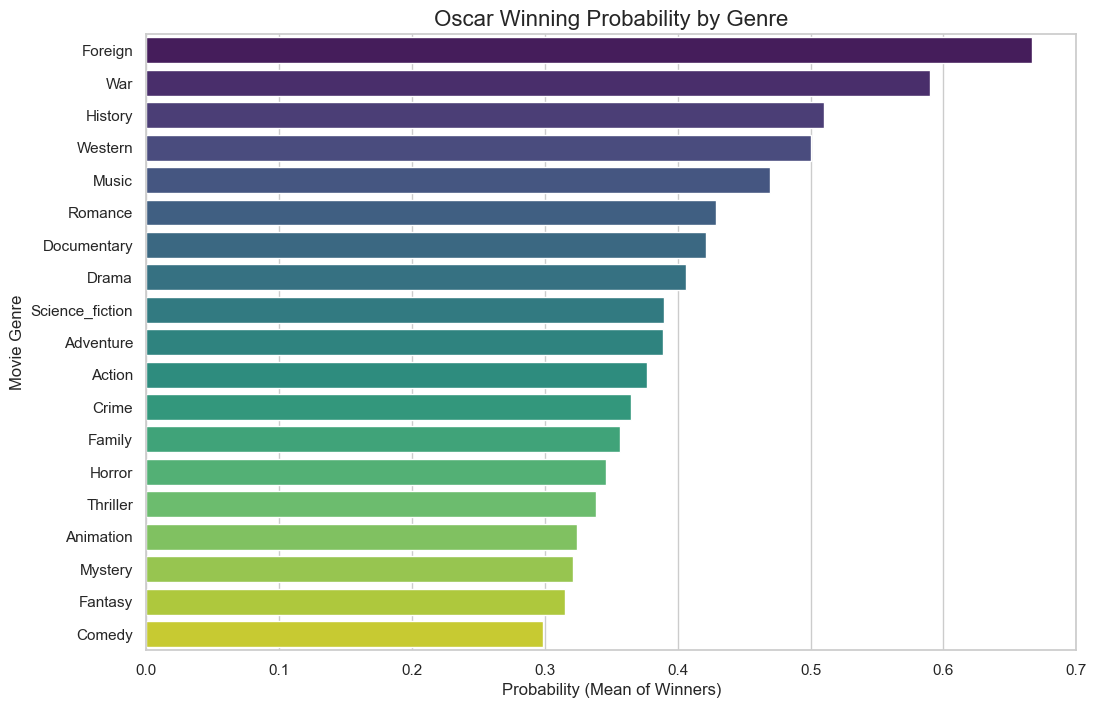

In [8]:
"""
Aggregating Oscar success rate by genre. This highlights which genres have the highest probability of winning.
"""

genre_cols = [col for col in df.columns if col.startswith('genre_')]
genre_win_rates = {}

for col in genre_cols:
    genre_name = col.replace('genre_', '').capitalize()
    win_rate = df[df[col] == 1]['is_oscar_winner'].mean()
    genre_win_rates[genre_name] = win_rate

genre_stats = pd.Series(genre_win_rates).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_stats.values, y=genre_stats.index, hue=genre_stats.index, palette='viridis')
plt.title('Oscar Winning Probability by Genre')
plt.xlabel('Probability (Mean of Winners)')
plt.ylabel('Movie Genre')
plt.show()